In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv(
    "../Data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
"../Data/raw/..."

'../Data/raw/...'

In [8]:
df.shape

(7043, 21)

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [10]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [11]:
df = df.dropna(subset=["TotalCharges"])

In [12]:
df.shape

(7032, 21)

In [13]:
df = df.drop(columns=["customerID"])

In [14]:
df.shape

(7032, 20)

In [15]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [16]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [17]:
df["Churn"].unique()

array([0, 1])

In [18]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [19]:
X.shape, y.shape

((7032, 19), (7032,))

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
X.shape

(7032, 30)

In [22]:
X.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 30), (1407, 30), (5625,), (1407,))

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled.shape, X_test_scaled.shape

((5625, 30), (1407, 30))

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [28]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [29]:
X_train_scaled
X_test_scaled
y_train
y_test

974     0
619     0
4289    0
3721    1
4533    0
       ..
4829    0
5176    0
2750    0
4432    0
2091    0
Name: Churn, Length: 1407, dtype: int64

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled.shape, X_test_scaled.shape

((5625, 30), (1407, 30))

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
import pandas as pd
import numpy as np

In [34]:
df = pd.read_csv(
    "../Data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [36]:
df = df.dropna(subset=["TotalCharges"])

In [37]:
df.shape

(7032, 21)

In [38]:
df = df.drop(columns=["customerID"])

In [39]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [40]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [41]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [42]:
X = pd.get_dummies(X, drop_first=True)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 30), (1407, 30), (5625,), (1407,))

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.7263681592039801

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


Confusion Matrix:
[[724 309]
 [ 76 298]]


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [49]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7732764747690121

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.66      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407


Confusion Matrix:
[[841 192]
 [127 247]]


In [50]:
X_train
X_test

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
974,0,59,75.95,4542.35,False,True,True,True,False,False,...,False,True,False,True,False,True,True,True,False,False
619,0,7,78.55,522.95,False,False,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False
4289,0,54,20.10,1079.45,False,False,False,True,False,False,...,True,False,True,False,False,True,False,False,False,True
3721,0,2,20.65,38.70,False,False,False,True,False,False,...,True,False,True,False,False,False,False,False,False,True
4533,0,71,105.15,7555.00,False,True,False,True,False,True,...,False,True,False,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4829,0,12,45.00,524.35,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
5176,0,26,45.80,1147.00,False,False,True,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2750,0,3,19.45,69.25,True,False,False,True,False,False,...,True,False,True,False,True,False,True,False,False,True
4432,0,37,40.55,1390.85,True,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,True


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [52]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7732764747690121

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.66      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407


Confusion Matrix:
[[841 192]
 [127 247]]


In [53]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [54]:
y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7782515991471215

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.60      0.52      0.55       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407


Confusion Matrix:
[[902 131]
 [181 193]]


In [55]:
results = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Churn Precision": [
        classification_report(y_test, y_pred_log, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["precision"]
    ],
    "Churn Recall": [
        classification_report(y_test, y_pred_log, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["recall"]
    ],
    "Churn F1": [
        classification_report(y_test, y_pred_log, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["f1-score"]
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1
0,Logistic Regression,0.726368,0.490939,0.796791,0.607543
1,Random Forest,0.773276,0.562642,0.660428,0.607626
2,XGBoost,0.778252,0.595679,0.516043,0.553009


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)

TotalCharges                      0.177109
tenure                            0.165505
MonthlyCharges                    0.151567
Contract_Two year                 0.060000
InternetService_Fiber optic       0.040955
PaymentMethod_Electronic check    0.037915
Contract_One year                 0.030595
OnlineSecurity_Yes                0.028014
gender_Male                       0.026028
PaperlessBilling_Yes              0.023258
TechSupport_Yes                   0.023240
Partner_Yes                       0.021419
OnlineBackup_Yes                  0.020901
Dependents_Yes                    0.020022
SeniorCitizen                     0.017845
dtype: float64

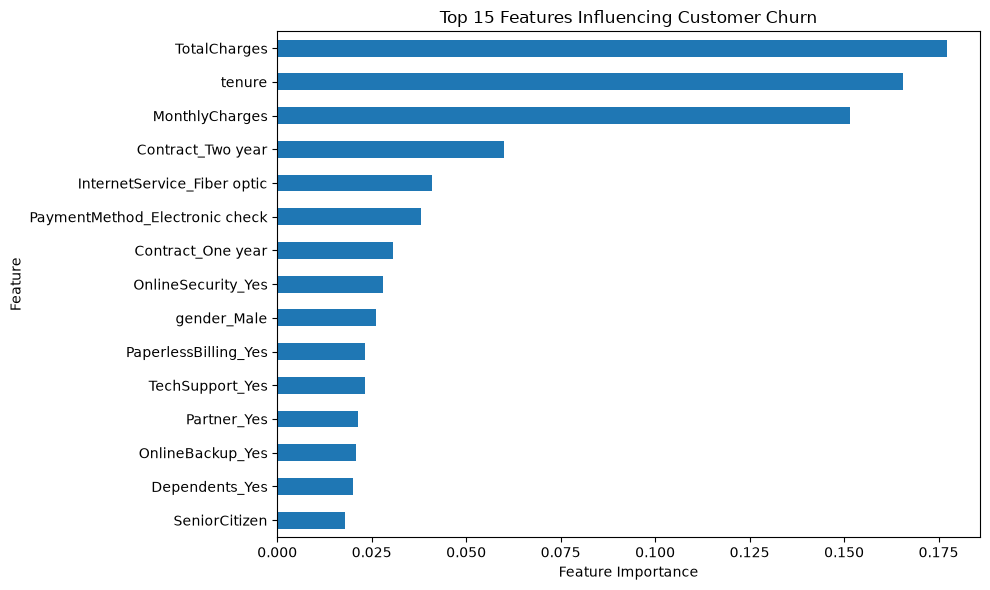

In [57]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [58]:
import joblib

joblib.dump(rf_model, "../rf_churn_model.pkl")
joblib.dump(X.columns.tolist(), "../feature_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [59]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\santh\OneDrive\Documents\major project\notebooks
['01_dataset_understanding.ipynb', '02_data_preprocessing.ipynb', 'app.py']


In [64]:
import os

print(os.listdir("../Data/raw"))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [65]:
df = pd.read_csv("../Data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [66]:
df.shape

(7043, 21)

In [67]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [68]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [69]:
import pandas as pd
import numpy as np

# Make a copy
data = df.copy()

# Remove customer ID
data = data.drop("customerID", axis=1)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Check missing values
print("Missing values:")
print(data.isnull().sum()[data.isnull().sum() > 0])

# Fill missing TotalCharges with median
data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

# Convert target variable Churn
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("\nDataset after basic preprocessing:")
print(data.shape)

print("\nChurn distribution:")
print(data["Churn"].value_counts())

Missing values:
TotalCharges    11
dtype: int64

Dataset after basic preprocessing:
(7043, 20)

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [70]:
# Convert categorical variables to numerical features

data_encoded = pd.get_dummies(
    data,
    drop_first=True
)

print("Encoded dataset shape:")
print(data_encoded.shape)

data_encoded.head()

Encoded dataset shape:
(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [71]:
# Features
X = data_encoded.drop("Churn", axis=1)

# Target
y = data_encoded["Churn"]

# Save feature column names
feature_columns = X.columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:")
print(len(feature_columns))

X shape: (7043, 30)
y shape: (7043,)

Number of features:
30


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 30)
Testing set: (1409, 30)


In [73]:
print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


In [74]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


c:\Users\santh\OneDrive\Documents\major project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [76]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [78]:
print("Models trained:")
print("1. Logistic Regression")
print("2. Random Forest")
print("3. XGBoost")

Models trained:
1. Logistic Regression
2. Random Forest
3. XGBoost


In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    roc_auc_score,
    classification_report
)

import pandas as pd


# Store all models
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}


# Store results
results = []


for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test)

    # Prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # Print metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Cohen's Kappa": kappa,
        "ROC-AUC": roc_auc
    })


# Create comparison DataFrame
results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    )
)


Logistic Regression
Accuracy: 0.8041
Precision: 0.6551
Recall: 0.5535
F1 Score: 0.6000
Cohen's Kappa: 0.4715
ROC-AUC: 0.8425

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Random Forest
Accuracy: 0.7899
Precision: 0.6336
Recall: 0.4947
F1 Score: 0.5556
Cohen's Kappa: 0.4207
ROC-AUC: 0.8265

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


XGBoost
Accuracy: 0.8034
Precision: 0.6570
Recall: 

,Model,Accuracy,Precision,Recall,F1 Score,Cohen's Kappa,ROC-AUC
2,XGBoost,0.803407,0.656958,0.542781,0.594436,0.466240,0.843201
0,Logistic Regression,0.804116,0.655063,0.553476,0.600000,0.471512,0.842463
1,Random Forest,0.789922,0.633562,0.494652,0.555556,0.420727,0.826493


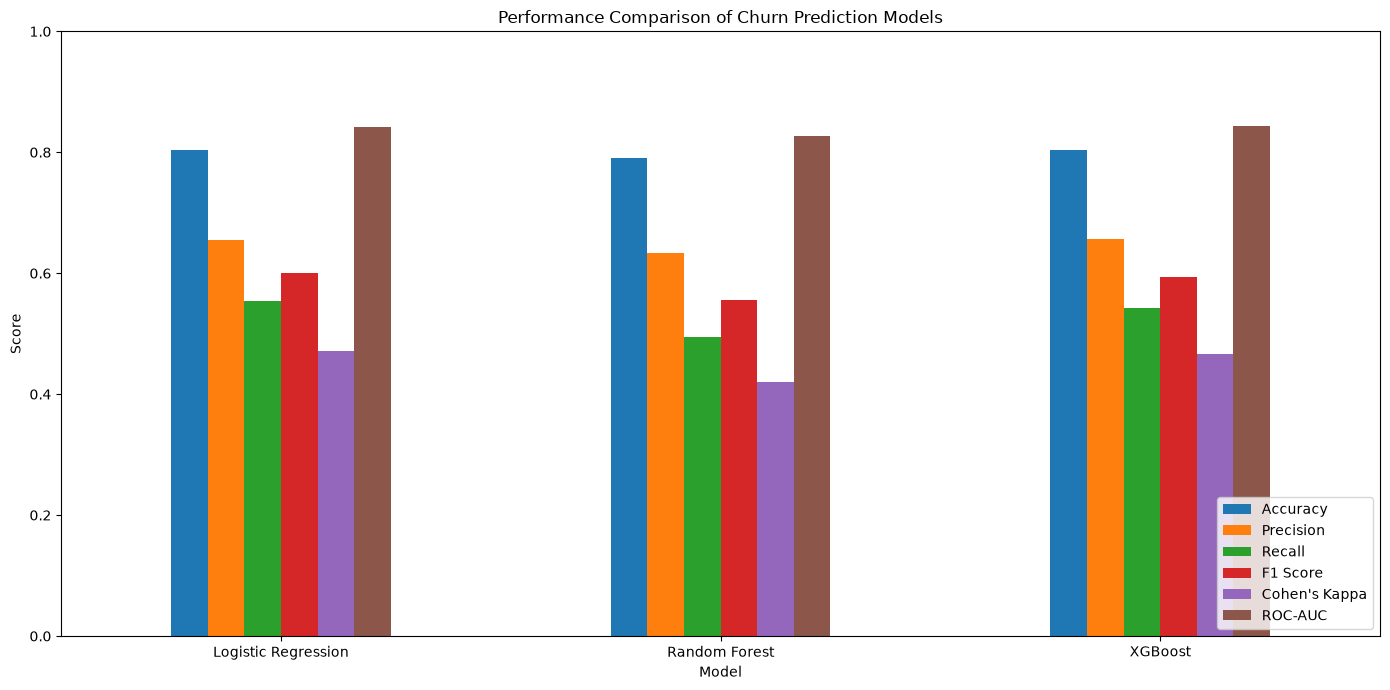

In [81]:
import matplotlib.pyplot as plt

# Set Model as index
plot_df = results_df.set_index("Model")

# Create bar chart
plot_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Cohen's Kappa",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Performance Comparison of Churn Prediction Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

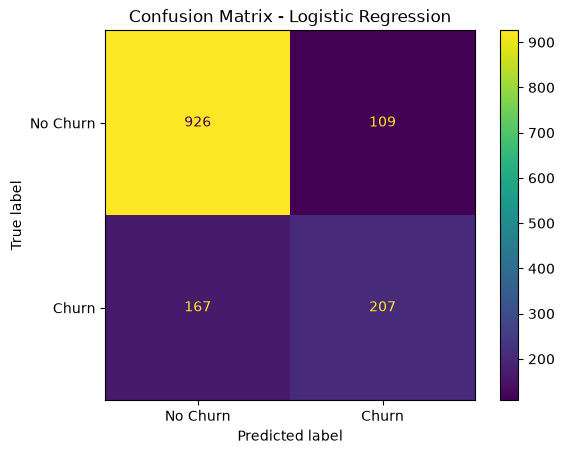

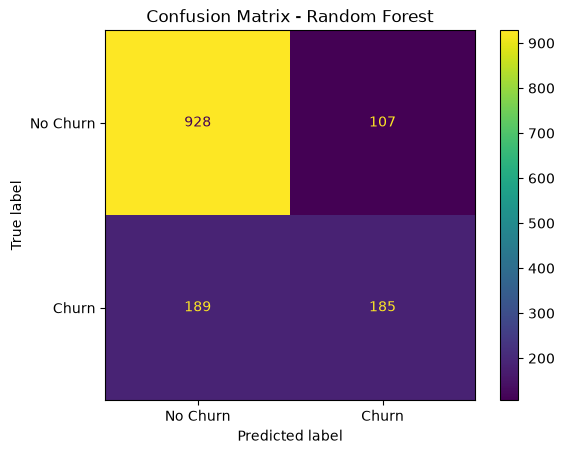

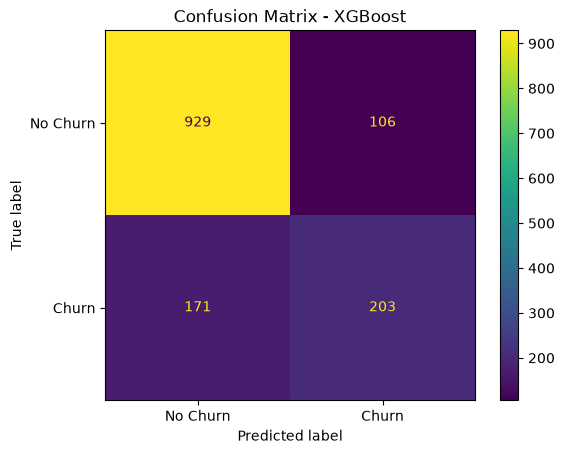

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Models to evaluate
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Create a confusion matrix for each model
for name, model in models.items():

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    print("\n" + "=" * 50)

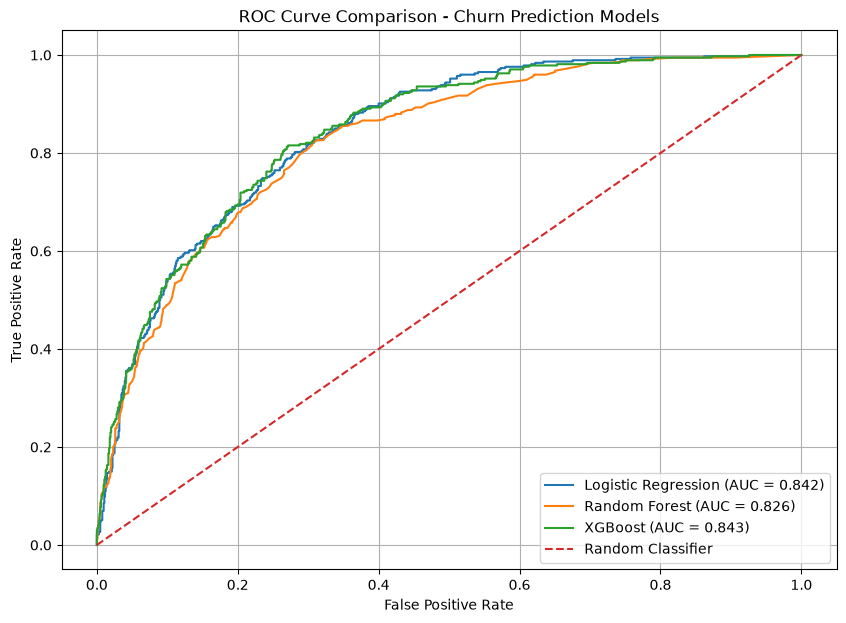

In [83]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Store models
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Get churn probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison - Churn Prediction Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()

plt.show()

In [84]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [85]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [86]:
# Check data types
print(df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]].dtypes)

tenure              int64
MonthlyCharges    float64
TotalCharges          str
Churn                 str
dtype: object


In [87]:
# Check for missing values
print(df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].isnull().sum())

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [88]:
# Convert TotalCharges from string to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check the data type again
print(df["TotalCharges"].dtype)

# Check if conversion created missing values
print("Missing values:", df["TotalCharges"].isnull().sum())

float64
Missing values: 11


In [89]:
# Check missing values
print("Missing values before:", df["TotalCharges"].isnull().sum())

# Fill missing TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify
print("Missing values after:", df["TotalCharges"].isnull().sum())

Missing values before: 11
Missing values after: 0


In [90]:
import numpy as np

# Create a copy for LTV modeling
ltv_df = df.copy()

# Estimated remaining lifetime in months
ltv_df["RemainingMonths"] = np.where(
    ltv_df["Churn"] == "Yes",
    0,
    24
)

# Estimated future LTV
ltv_df["EstimatedLTV"] = (
    ltv_df["MonthlyCharges"]
    * ltv_df["RemainingMonths"]
)

# Display the important columns
ltv_df[
    [
        "tenure",
        "MonthlyCharges",
        "Churn",
        "RemainingMonths",
        "EstimatedLTV"
    ]
].head(10)

,tenure,MonthlyCharges,Churn,RemainingMonths,EstimatedLTV
0,1,29.85,No,24,716.4
1,34,56.95,No,24,1366.8
2,2,53.85,Yes,0,0.0
3,45,42.30,No,24,1015.2
4,2,70.70,Yes,0,0.0
5,8,99.65,Yes,0,0.0
6,22,89.10,No,24,2138.4
7,10,29.75,No,24,714.0
8,28,104.80,Yes,0,0.0
9,62,56.15,No,24,1347.6


In [91]:
# Features for LTV prediction
X_ltv = ltv_df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]

# Target variable
y_ltv = ltv_df["EstimatedLTV"]

print("Feature shape:", X_ltv.shape)
print("Target shape:", y_ltv.shape)

print("\nFeatures:")
print(X_ltv.head())

print("\nTarget:")
print(y_ltv.head())

Feature shape: (7043, 3)
Target shape: (7043,)

Features:
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65

Target:
0     716.4
1    1366.8
2       0.0
3    1015.2
4       0.0
Name: EstimatedLTV, dtype: float64


In [92]:
from sklearn.model_selection import train_test_split

X_ltv_train, X_ltv_test, y_ltv_train, y_ltv_test = train_test_split(
    X_ltv,
    y_ltv,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_ltv_train.shape)
print("Testing data:", X_ltv_test.shape)

Training data: (5634, 3)
Testing data: (1409, 3)


In [93]:
from sklearn.ensemble import RandomForestRegressor

# Create the regression model
ltv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
ltv_model.fit(
    X_ltv_train,
    y_ltv_train
)

print("LTV Regression Model trained successfully!")

LTV Regression Model trained successfully!


In [94]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Make predictions
y_ltv_pred = ltv_model.predict(X_ltv_test)

# Calculate evaluation metrics
mae = mean_absolute_error(
    y_ltv_test,
    y_ltv_pred
)

mse = mean_squared_error(
    y_ltv_test,
    y_ltv_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_ltv_test,
    y_ltv_pred
)

# Display results
print("LTV MODEL PERFORMANCE")
print("=" * 40)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

LTV MODEL PERFORMANCE
MAE: 472.70
RMSE: 725.24
R² Score: 0.3624


In [95]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [96]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [97]:
# Create SHAP Tree Explainer
explainer = shap.TreeExplainer(rf_model)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [98]:
# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [99]:
print("Type:", type(shap_values))
print("Shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
Shape: (1409, 30, 2)


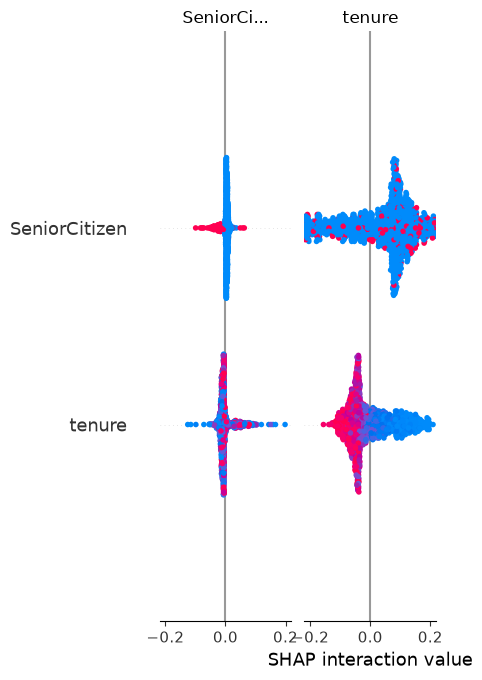

In [100]:
# Create SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [102]:
# Select one customer from the test dataset
customer_index = 0

# Get that customer's data
customer_data = X_test.iloc[[customer_index]]

# Display the customer
customer_data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,0,72,114.05,8468.2,True,True,True,True,False,True,...,False,True,False,True,False,True,True,True,False,False


In [106]:
# Predict churn probability
customer_probability = rf_model.predict_proba(customer_data)[0][1]

print(
    f"Churn Probability: {customer_probability * 100:.2f}%"
)

Churn Probability: 0.00%


In [107]:
# Create SHAP explanation for the selected customer
shap_explanation = explainer(customer_data)

print("SHAP explanation created successfully!")

SHAP explanation created successfully!


In [108]:
# Display SHAP values
shap_explanation

.values =
array([[[ 2.73632978e-03, -2.73632978e-03],
        [ 8.78089667e-02, -8.78089667e-02],
        [-9.82743855e-03,  9.82743855e-03],
        [ 4.64447745e-02, -4.64447745e-02],
        [ 1.17532167e-03, -1.17532167e-03],
        [ 3.53459818e-03, -3.53459818e-03],
        [ 1.21834587e-02, -1.21834587e-02],
        [ 1.24559063e-04, -1.24559063e-04],
        [ 8.63744771e-05, -8.63744771e-05],
        [-4.92635179e-03,  4.92635179e-03],
        [-2.76654846e-02,  2.76654846e-02],
        [-2.25190007e-03,  2.25190007e-03],
        [-2.86037083e-03,  2.86037083e-03],
        [ 3.19131449e-02, -3.19131449e-02],
        [-1.97069591e-03,  1.97069591e-03],
        [ 1.11115720e-02, -1.11115720e-02],
        [-3.07969961e-03,  3.07969961e-03],
        [ 4.09095954e-03, -4.09095954e-03],
        [-3.23472865e-03,  3.23472865e-03],
        [ 2.04787284e-02, -2.04787284e-02],
        [-2.30201397e-03,  2.30201397e-03],
        [-5.24428392e-03,  5.24428392e-03],
        [-2.68073335e-

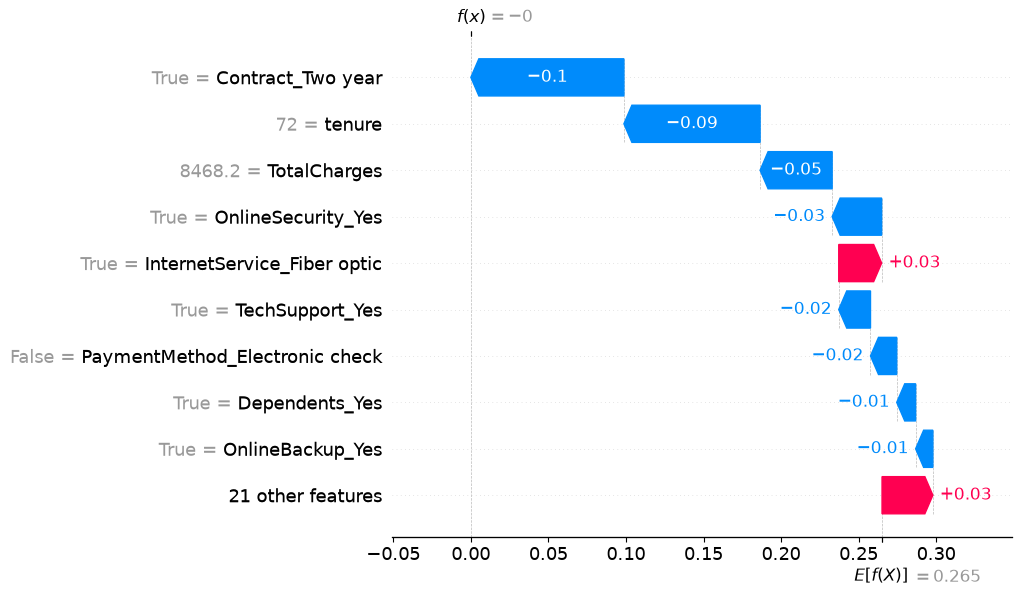

In [110]:
shap.plots.waterfall(
    shap_explanation[0,:,1]
)

In [111]:
import joblib

# Save the trained LTV model
joblib.dump(
    ltv_model,
    "../ltv_model.pkl"
)

print("LTV model saved successfully!")

LTV model saved successfully!


In [112]:
joblib.dump(
    logistic_model,
    "../logistic_regression_model.pkl"
)

joblib.dump(
    rf_model,
    "../rf_churn_model.pkl"
)

joblib.dump(
    xgb_model,
    "../xgboost_churn_model.pkl"
)

print("All classification models saved successfully!")

All classification models saved successfully!


In [113]:
joblib.dump(
    logistic_model,
    "../logistic_regression_model.pkl"
)

joblib.dump(
    xgb_model,
    "../xgboost_churn_model.pkl"
)

joblib.dump(
    ltv_model,
    "../ltv_model.pkl"
)

print("Additional models saved successfully!")

Additional models saved successfully!
